In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

In [2]:


def aggregate_model_frames(frames, model_name):
    combined = pd.concat(frames, ignore_index=True)
    grouped = combined.groupby("filename", as_index=False).mean(numeric_only=True)
    grouped["dataset_name"] = grouped["filename"].str.split("_").str[1]

    keep_cols = ["filename", "dataset_name", "AUC-PR", "AUC-ROC", "Standard-F1"]
    existing_cols = [c for c in keep_cols if c in grouped.columns]

    out = grouped[existing_cols].copy()
    out["model"] = model_name
    return out


def load_seed_overlapping_frames(model_name):
    """Load all seed*_overlapping.csv files from results/evaluation_best/{model_name}"""
    base_path = os.path.join("../results/evaluation_best", model_name)
    if not os.path.exists(base_path):
        return None
    files = sorted(
        f for f in os.listdir(base_path)
        if f.startswith("seed") and f.endswith("_overlapping.csv")
    )
    if not files:
        return None
    return [pd.read_csv(os.path.join(base_path, fname)) for fname in files]


# Check which models have seed*_overlapping files
available_models = os.listdir("../results/evaluation_best")
models_with_seed = [m for m in available_models if os.path.isdir(os.path.join("../results/evaluation_best", m))]
print(f"Models available in evaluation_best: {models_with_seed}")

# Build DataFrames based on available seed files
dataframes = []
# DLinear
if "DLinear" in models_with_seed:
    dlinear_frames = load_seed_overlapping_frames("DLinear")
    if dlinear_frames:
        dlinear_df = aggregate_model_frames(dlinear_frames, "DLinear")

        dataframes.append(dlinear_df)
# Rec-PCA
pca_path = "../results/evaluation_best/Rec-PCA/seed0_overlapping.csv"
pca_df = aggregate_model_frames([pd.read_csv(pca_path)], "Rec-PCA")
dataframes.append(pca_df)
pca_frames = [pd.read_csv(pca_path)]
grouped_df = (
    pd.concat(pca_frames, ignore_index=True)
    .groupby("filename", as_index=False)
    .mean(numeric_only=True)
)
grouped_df["dataset_name"] = grouped_df["filename"].str.split("_").str[1]


# TimesNet
if "TimesNet" in models_with_seed:
    timesnet_frames = load_seed_overlapping_frames("TimesNet")
    if timesnet_frames:
        timesnet_df = aggregate_model_frames(timesnet_frames, "TimesNet")
        dataframes.append(timesnet_df)

# FEDformer (note: capitalization)
if "FEDformer" in models_with_seed:
    fedformer_frames = load_seed_overlapping_frames("FEDformer")
    if fedformer_frames:
        fedformer_df = aggregate_model_frames(fedformer_frames, "FEDFormer")
        dataframes.append(fedformer_df)

# Autoformer
if "Autoformer" in models_with_seed:
    autoformer_frames = load_seed_overlapping_frames("Autoformer")
    if autoformer_frames:
        autoformer_df = aggregate_model_frames(autoformer_frames, "Autoformer")
        dataframes.append(autoformer_df)

# Transformer
if "Transformer" in models_with_seed:
    transformer_frames = load_seed_overlapping_frames("Transformer")
    if transformer_frames:
        transformer_df = aggregate_model_frames(transformer_frames, "Transformer")
        dataframes.append(transformer_df)
        
# AutoEncoder
if "AutoEncoder" in models_with_seed:
    autoencoder_frames = load_seed_overlapping_frames("AutoEncoder")
    if autoencoder_frames:
        autoencoder_df = aggregate_model_frames(autoencoder_frames, "AutoEncoder")
        dataframes.append(autoencoder_df)

# Combined table used by plotting cells
if dataframes:
    model_auc_df = pd.concat(dataframes, ignore_index=True)
    ordered_cols = ["model", "dataset_name", "filename", "AUC-PR", "rel_normal", "rel_abnormal"]
    model_auc_df = model_auc_df[[c for c in ordered_cols if c in model_auc_df.columns]]
    print(f"Loaded {len(model_auc_df)} rows from {len(dataframes)} models")
else:
    raise ValueError("No model data loaded")

Models available in evaluation_best: ['AutoEncoder', 'TimesNet', 'Rec-PCA', 'Autoformer', 'Transformer', 'FEDformer', 'DLinear']
Loaded 5754 rows from 7 models


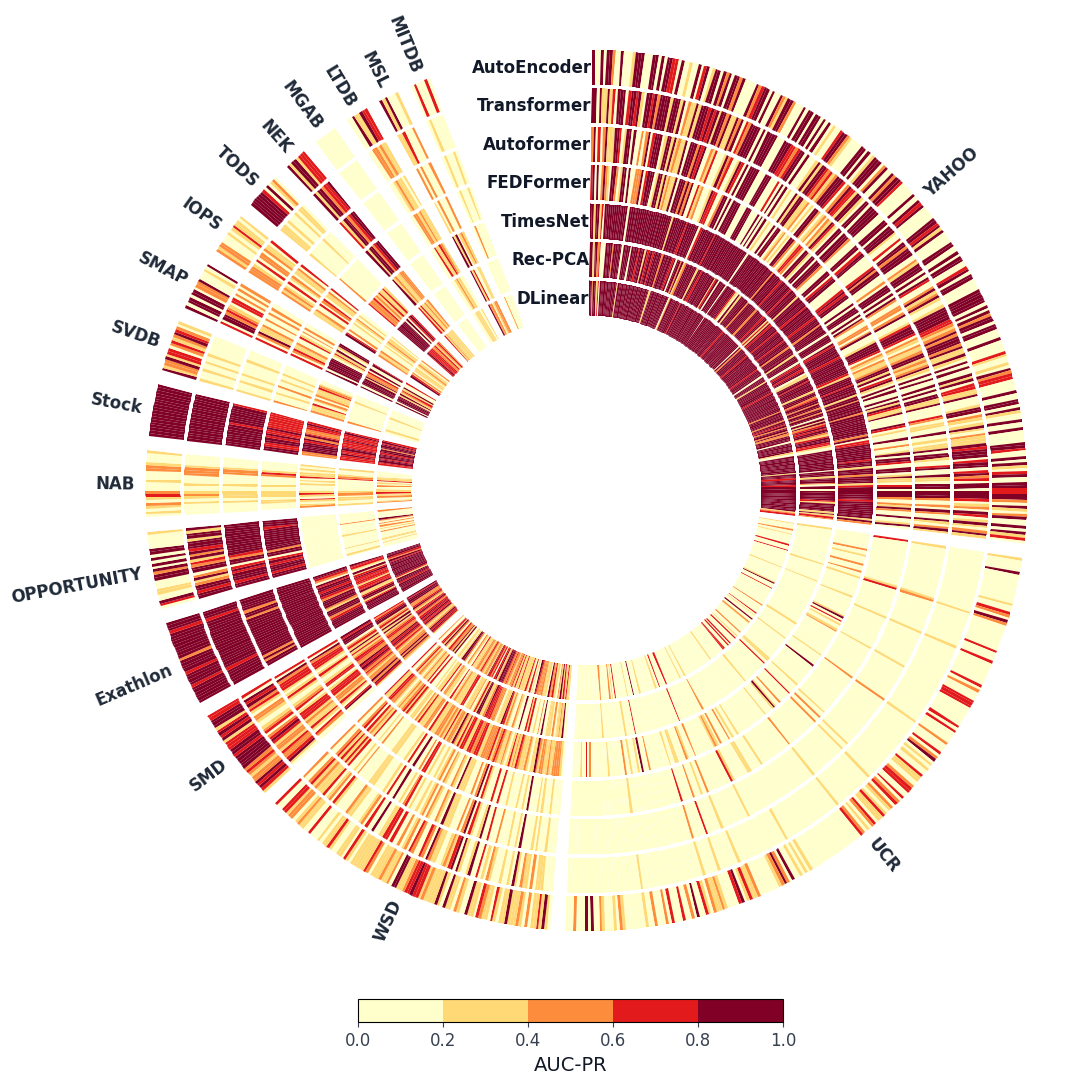

In [3]:
def prepare_plot_df(df_in, value_col):
    required_cols = {"model", "dataset_name", "filename", value_col}
    missing = required_cols - set(df_in.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df_out = df_in.dropna(subset=["model", "dataset_name", "filename", value_col]).copy()
    if df_out.empty:
        raise ValueError("No rows available after dropping missing values")
    return df_out


def build_bins(df_in, datasets, label_space=10, gap_cells=10, padding_space=40):
    bin_records = []
    dataset_spans = []
    cursor = 0

    for _ in range(label_space):
        bin_records.append({"dataset_name": None, "filename": None, "is_gap": True})
        cursor += 1

    for ds_i, ds in enumerate(datasets):
        filenames = sorted(df_in.loc[df_in["dataset_name"] == ds, "filename"].unique().tolist())
        start_idx = cursor
        for fn in filenames:
            bin_records.append({"dataset_name": ds, "filename": fn, "is_gap": False})
            cursor += 1
        end_idx = cursor
        dataset_spans.append((ds, start_idx, end_idx))

        if ds_i < len(datasets) - 1:
            for _ in range(gap_cells):
                bin_records.append({"dataset_name": None, "filename": None, "is_gap": True})
                cursor += 1

    for _ in range(padding_space):
        bin_records.append({"dataset_name": None, "filename": None, "is_gap": True})
        cursor += 1

    return bin_records, dataset_spans


def build_heat_matrix(df_in, models, bin_records, value_col):
    total_bins = len(bin_records)
    if total_bins == 0:
        raise ValueError("No bins available to plot")

    heat = np.full((len(models), total_bins), np.nan, dtype=float)
    for mi, model_name in enumerate(models):
        model_series = (
            df_in[df_in["model"] == model_name]
            .drop_duplicates(subset=["dataset_name", "filename"], keep="last")
            .set_index(["dataset_name", "filename"])[value_col]
        )

        for bi, rec in enumerate(bin_records):
            if rec["is_gap"]:
                continue
            key = (rec["dataset_name"], rec["filename"])
            if key in model_series.index:
                heat[mi, bi] = float(model_series.loc[key])

    return heat


def build_radial_layout(heat, inner_radius=1.0, ring_thickness=0.24, ring_gap=0.06):
    n_models = heat.shape[0]
    total_bins = heat.shape[1]

    plot_rows = 2 * n_models - 1
    heat_plot = np.full((plot_rows, total_bins), np.nan, dtype=float)
    for mi in range(n_models):
        heat_plot[2 * mi, :] = heat[mi, :]

    r_widths = [ring_thickness if (ri % 2 == 0) else ring_gap for ri in range(plot_rows)]
    r_edges = np.empty(plot_rows + 1, dtype=float)
    r_edges[0] = inner_radius
    for ri, w in enumerate(r_widths):
        r_edges[ri + 1] = r_edges[ri] + w

    return heat_plot, r_edges


def add_dataset_labels(ax, dataset_spans, theta_edges, outer_radius, min_label_width=0.0):
    for ds_name, s_idx, e_idx in dataset_spans:
        th0 = theta_edges[s_idx]
        th1 = theta_edges[e_idx]
        width = th1 - th0

        if width < min_label_width:
            continue

        theta_mid = 0.5 * (th0 + th1)
        display_angle = (90.0 - np.degrees(theta_mid)) % 360.0

        if 90.0 < display_angle < 270.0:
            text_rot = display_angle + 180.0
            ha = "right"
        else:
            text_rot = display_angle
            ha = "left"

        ax.text(
            theta_mid,
            outer_radius + 0.06,
            str(ds_name),
            fontsize=12,
            fontweight="bold",
            color="#1f2937",
            rotation=text_rot,
            rotation_mode="anchor",
            ha=ha,
            va="center",
        )


def add_model_labels(ax, models, r_edges, theta_edges, label_space):
    label_space_angle = theta_edges[label_space]
    for mi, model_name in enumerate(models):
        r_mid = 0.5 * (r_edges[2 * mi] + r_edges[2 * mi + 1])
        ax.text(
            label_space_angle * 0.92,
            r_mid,
            model_name,
            fontsize=12,
            fontweight="bold",
            color="#111827",
            ha="right",
            va="center",
        )



df = model_auc_df.copy()


value_col = "AUC-PR"
df = prepare_plot_df(df, value_col)

# Keep model order as first appearance
dataset_lengths = (
    df.groupby("dataset_name")["filename"]
    .nunique()
    .sort_values(ascending=False)
)
models = list(dict.fromkeys(df["model"].tolist()))
datasets = dataset_lengths[dataset_lengths > 5].index.tolist()

# Layout controls
label_space = 2
gap_cells = 5
padding_space = 55
inner_radius = 1.0
ring_thickness = 0.2
ring_gap = 0.02

bin_records, dataset_spans = build_bins(
    df,
    datasets,
    label_space=label_space,
    gap_cells=gap_cells,
    padding_space=padding_space,
)
heat = build_heat_matrix(df, models, bin_records, value_col=value_col)
heat_plot, r_edges = build_radial_layout(
    heat,
    inner_radius=inner_radius,
    ring_thickness=ring_thickness,
    ring_gap=ring_gap,
)

theta_edges = np.linspace(0, 2 * np.pi, len(bin_records) + 1)
outer_radius = r_edges[-1]
Theta, R = np.meshgrid(theta_edges, r_edges)

# Figure styling
fig, ax = plt.subplots(figsize=(12.5, 12.5), subplot_kw={"projection": "polar"}, facecolor="#ffffff")
ax.set_facecolor("#ffffff")

# Discrete color steps
vmin = np.nanmin(heat)
vmax = np.nanmax(heat)
n_steps = 5
bounds = np.linspace(vmin, vmax, n_steps + 1)
cmap = plt.get_cmap("YlOrRd", n_steps).copy()
cmap.set_bad(color="#ffffff", alpha=1.0)
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)

mesh = ax.pcolormesh(
    Theta,
    R,
    heat_plot,
    cmap=cmap,
    norm=norm,
    shading="flat",
    edgecolors="none",
    linewidth=0,
    antialiased=True,
    snap=True,
)

# White donut center
ax.bar(
    0.0,
    height=inner_radius,
    width=2 * np.pi,
    bottom=0.0,
    align="edge",
    color="#ffffff",
    edgecolor="none",
    zorder=0,
)

add_dataset_labels(ax, dataset_spans, theta_edges, outer_radius, min_label_width=0.0)
add_model_labels(ax, models, r_edges, theta_edges, label_space)

# Clean framing
ax.set_yticks([])
ax.set_ylim(0, outer_radius + 0.23)
ax.set_xticks([])
ax.grid(False)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.spines["polar"].set_visible(False)

# Colorbar styling
ticks = np.linspace(vmin, vmax, 6)
cax = fig.add_axes([0.33, 0.07, 0.34, 0.018])
cbar = plt.colorbar(
    mesh,
    cax=cax,
    orientation="horizontal",
    boundaries=bounds,
    ticks=ticks,
)
cbar.set_label("AUC-PR", fontsize=14, color="#111827")
cbar.ax.tick_params(labelsize=12, colors="#374151")

plt.savefig("../Figures/model_comparison_polar_heatmap.pdf", bbox_inches="tight")
plt.savefig("../Figures/model_comparison_polar_heatmap.png", bbox_inches="tight")

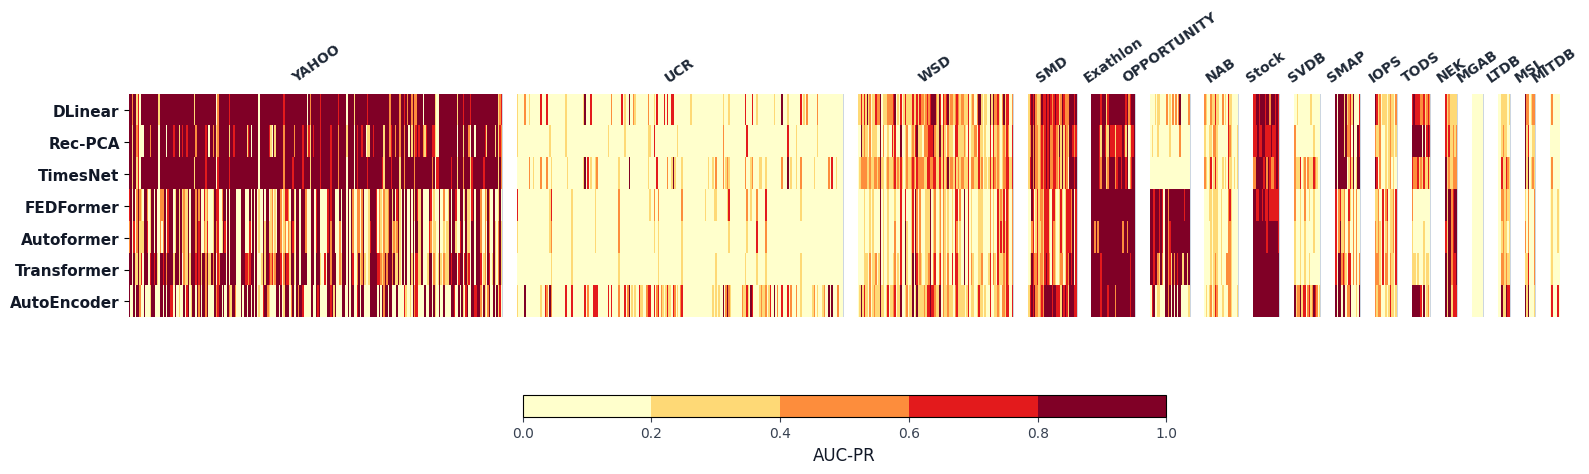

In [4]:
df_lin = model_auc_df.copy()



required_cols = {"model", "dataset_name", "filename", "AUC-PR"}
missing = required_cols - set(df_lin.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_lin = df_lin.dropna(subset=["model", "dataset_name", "filename", "AUC-PR"]).copy()
if df_lin.empty:
    raise ValueError("No rows available after dropping missing values")

models_lin = list(dict.fromkeys(df_lin["model"].tolist()))
dataset_lengths_lin = (
    df_lin.groupby("dataset_name")["filename"]
    .nunique()
    .sort_values(ascending=False)
)
datasets_lin = dataset_lengths_lin[dataset_lengths_lin > 5].index.tolist()
gap_cells_lin = 10

# Build linear bin layout with small NaN gaps between datasets
bin_records_lin = []
dataset_spans_lin = []
cursor_lin = 0
for ds_i, ds in enumerate(datasets_lin):
    fns = sorted(df_lin.loc[df_lin["dataset_name"] == ds, "filename"].unique().tolist())
    s_idx = cursor_lin
    for fn in fns:
        bin_records_lin.append({"dataset_name": ds, "filename": fn, "is_gap": False})
        cursor_lin += 1
    e_idx = cursor_lin
    dataset_spans_lin.append((ds, s_idx, e_idx))

    if ds_i < len(datasets_lin) - 1:
        for _ in range(gap_cells_lin):
            bin_records_lin.append({"dataset_name": None, "filename": None, "is_gap": True})
            cursor_lin += 1

n_models_lin = len(models_lin)
total_bins_lin = len(bin_records_lin)
heat_lin = np.full((n_models_lin, total_bins_lin), np.nan, dtype=float)

for mi, model_name in enumerate(models_lin):
    model_series = (
        df_lin[df_lin["model"] == model_name]
        .drop_duplicates(subset=["dataset_name", "filename"], keep="last")
        .set_index(["dataset_name", "filename"])["AUC-PR"]
    )
    for bi, rec in enumerate(bin_records_lin):
        if rec["is_gap"]:
            continue
        key = (rec["dataset_name"], rec["filename"])
        if key in model_series.index:
            heat_lin[mi, bi] = float(model_series.loc[key])

vmin_lin = np.nanmin(heat_lin)
vmax_lin = np.nanmax(heat_lin)
n_steps_lin = 5
bounds_lin = np.linspace(vmin_lin, vmax_lin, n_steps_lin + 1)
cmap_lin = plt.get_cmap("YlOrRd", n_steps_lin).copy()
cmap_lin.set_bad(color="#ffffff", alpha=1.0)
norm_lin = BoundaryNorm(bounds_lin, ncolors=cmap_lin.N, clip=True)

fig, ax = plt.subplots(figsize=(16, 4.8), facecolor="#ffffff")
ax.set_facecolor("#ffffff")

im = ax.imshow(heat_lin, aspect="auto", cmap=cmap_lin, norm=norm_lin, interpolation="nearest")

# Y axis (models)
ax.set_yticks(np.arange(n_models_lin))
ax.set_yticklabels(models_lin, fontsize=11, fontweight="bold", color="#111827")

# Remove dense x tick labels; replace with dataset labels at group centers
ax.set_xticks([])
for ds_name, s_idx, e_idx in dataset_spans_lin:
    x_mid = 0.5 * (s_idx + e_idx - 1)
    ax.text(
        x_mid,
        -0.8,
        str(ds_name),
        ha="center",
        va="bottom",
        rotation=35,
        fontsize=10,
        fontweight="bold",
        color="#1f2937",
        clip_on=False,
    )

# Light separators between dataset blocks
for _, _, e_idx in dataset_spans_lin[:-1]:
    ax.axvline(e_idx - 0.5, color="#cbd5e1", linewidth=0.7)

for spine in ax.spines.values():
    spine.set_visible(False)


cbar = plt.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.22,
    shrink=0.45,
    aspect=30,
    boundaries=bounds_lin,
    ticks=np.linspace(vmin_lin, vmax_lin, 6),
)
cbar.set_label("AUC-PR", fontsize=12, color="#111827")
cbar.ax.tick_params(labelsize=10, colors="#374151")

plt.tight_layout()
plt.savefig("../Figures/model_comparison_linear_heatmap.pdf", bbox_inches="tight")
plt.show()